# Interpreting and Evaluating Probabilistic Water-Demand Forecasts

The previous notebooks established a forecasting system with two distinct pieces:

1. **Linear quantile regression (QR)** estimates the conditional 10th, 50th and 90th percentiles of one-day-ahead water demand.
2. **Adaptive Conformal Inference (ACI)** calibrates the resulting central quantile band sequentially using recent forecast errors.

Notebook 04 selected **two-sided ACI with a 180-day conformity-score history** as the preferred calibration method. This notebook builds on that fixed specification in two stages.

First, it interprets the chronological 2023–March 2025 probabilistic forecasts to ask what the selected system reveals about **when water demand is difficult to predict**. The analysis focuses on forecast width, weather, demand regimes, tail behavior and remaining calibration error.

Second, after all probabilistic modeling choices have been fixed, it performs a **final out-of-sample probabilistic evaluation** over April 2025–March 2026. The linear quantile regressors are fitted once using all eligible observations through March 31, 2025, while the selected ACI controller is continued sequentially from its pre-evaluation state without retuning its method, window length or adaptation rate.

The analysis therefore addresses five questions:

1. **Does weather relate to forecast uncertainty as well as expected demand?**
2. **Is uncertainty distributed symmetrically above and below the predicted median?**
3. **Under which conditions does calibration remain most difficult?**
4. **What characterizes days for which the forecasting system reports unusually high uncertainty?**
5. **Does the selected probabilistic system generalize to the subsequent out-of-sample year?**

## Why use prediction-level interpretation?

Matrix B contains many correlated lagged, rolling, calendar and weather predictors. The unregularized QR coefficient vector is therefore not the most reliable object for substantive interpretation.

Instead, this notebook studies the **forecast distributions themselves**: predicted medians, quantile spreads, calibrated interval widths and empirical coverage across observable regimes.

## Weather information boundary

The deployable forecasting scenario uses lagged observed weather rather than same-day realized weather. To preserve that interpretation, the primary weather diagnostics use the **previous day's maximum temperature and precipitation**.

For the 2023–March 2025 interpretation analysis, these variables are joined to chronologically out-of-fold forecasts. The final April 2025–March 2026 evaluation uses the same leakage-safe feature construction and preserves the one-day-ahead information boundary.

## 1. Load the selected probabilistic forecasts

Notebook 04 saves the selected ACI intervals for the 2023–March 2025 chronological evaluation period to `reports/probabilistic/calibration/`.

Sections 2–7 treat those forecasts as fixed and use them only for interpretation. No model fitting or calibration-method selection is performed during those analyses.

For each evaluation date we retain:

- the raw QR quantiles $q_{.10}, q_{.50}, q_{.90}$;
- the selected ACI lower and upper endpoints;
- observed water demand; and
- prior-day weather constructed from the processed daily dataset.

Section 8 then performs a separate final out-of-sample evaluation over April 2025–March 2026. The selected QR specification is refitted once using all eligible pre-evaluation observations, while the previously selected ACI configuration is continued sequentially without further method or hyperparameter selection.

In [3]:
from pathlib import Path
import importlib.metadata as metadata
import os
import platform
import subprocess
import sys

REPOSITORY_NAME = "municipal-water-demand-forecasting"
REPOSITORY_URL = "https://github.com/fureyc/municipal-water-demand-forecasting.git"

def find_repository_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (
            (candidate / "config" / "modeling.yml").exists()
            and (candidate / "data" / "processed" / "fort_collins_daily_water_weather.csv").exists()
        ):
            return candidate
    return None

repo_root = find_repository_root()

if repo_root is None:
    clone_parent = Path("/content") if Path("/content").exists() else Path.cwd()
    clone_target = clone_parent / REPOSITORY_NAME
    if not clone_target.exists():
        subprocess.run(["git", "clone", "--depth", "1", REPOSITORY_URL, str(clone_target)], check=True)
    repo_root = find_repository_root(clone_target)

if repo_root is None:
    raise FileNotFoundError("Could not locate the project repository.")

os.chdir(repo_root)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print("Repository root:", repo_root)

Repository root: /content/municipal-water-demand-forecasting


In [4]:
subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "-r", str(repo_root / "requirements.txt")],
    check=True,
)
print("Dependencies are available.")

Dependencies are available.


In [5]:
from collections import deque
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display
from sklearn.linear_model import QuantileRegressor
from sklearn.metrics import mean_pinball_loss
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from src.features.build_forecasting_features import (
    load_and_build_forecasting_features,
)

In [6]:
DATE_COLUMN = "date"
TARGET_COLUMN = "water_demand_mgd"

TEMP_COLUMN = "tmax_f"
PRECIP_COLUMN = "precipitation_in"

EVALUATION_START = pd.Timestamp("2023-01-01")
EVALUATION_END = pd.Timestamp("2025-03-31")

TEMP_GROUP_LABELS = ["Coolest 20%", "20–40%", "40–60%", "60–80%", "Warmest 20%"]
DEMAND_GROUP_LABELS = ["Lowest 20%", "20–40%", "40–60%", "60–80%", "Highest 20%"]

versions = pd.Series(
    {
        "Python": platform.python_version(),
        "NumPy": metadata.version("numpy"),
        "pandas": metadata.version("pandas"),
        "Matplotlib": metadata.version("matplotlib"),
    },
    name="version",
)

display(versions.to_frame())

,version
Python,3.12.13
NumPy,2.0.2
pandas,2.2.3
Matplotlib,3.10.0


In [7]:
CALIBRATION_DIR = repo_root / "reports" / "probabilistic" / "calibration"
ACI_PATH = CALIBRATION_DIR / "two_sided_aci_180d_intervals.csv"

if not ACI_PATH.exists():
    candidates = sorted(CALIBRATION_DIR.glob("*aci*180d*intervals.csv"))
    if len(candidates) == 1:
        ACI_PATH = candidates[0]
    else:
        raise FileNotFoundError(
            "Could not find the selected ACI interval output. Run Notebook 04 first and confirm that "
            "'two_sided_aci_180d_intervals.csv' was saved."
        )

aci = pd.read_csv(ACI_PATH, parse_dates=["date"])

required_aci_columns = {"date", "y_true", "q10", "q50", "q90", "lower", "upper"}
missing = required_aci_columns - set(aci.columns)
if missing:
    raise ValueError(f"Selected ACI output is missing columns: {sorted(missing)}")

aci = (
    aci.loc[aci["date"].between(EVALUATION_START, EVALUATION_END, inclusive="both")]
    .sort_values("date")
    .reset_index(drop=True)
)

print("Selected ACI file:", ACI_PATH)
print("Evaluation observations:", len(aci))
print("Range:", aci["date"].min().date(), "through", aci["date"].max().date())

Selected ACI file: /content/municipal-water-demand-forecasting/reports/probabilistic/calibration/two_sided_aci_180d_intervals.csv
Evaluation observations: 821
Range: 2023-01-01 through 2025-03-31


In [8]:
DATA_PATH = repo_root / "data" / "processed" / "fort_collins_daily_water_weather.csv"

weather = pd.read_csv(DATA_PATH, parse_dates=[DATE_COLUMN]).sort_values(DATE_COLUMN)

required_weather_columns = {DATE_COLUMN, TARGET_COLUMN, TEMP_COLUMN, PRECIP_COLUMN}
missing_weather = required_weather_columns - set(weather.columns)
if missing_weather:
    raise ValueError(f"Processed data is missing expected columns: {sorted(missing_weather)}")

weather["prior_day_tmax_f"] = weather[TEMP_COLUMN].shift(1)
weather["prior_day_precipitation_in"] = weather[PRECIP_COLUMN].shift(1)

weather_context = weather[
    [DATE_COLUMN, TEMP_COLUMN, PRECIP_COLUMN, "prior_day_tmax_f", "prior_day_precipitation_in"]
].copy()

analysis = aci.merge(
    weather_context,
    left_on="date",
    right_on=DATE_COLUMN,
    how="left",
    validate="one_to_one",
)

if DATE_COLUMN != "date":
    analysis = analysis.drop(columns=[DATE_COLUMN])

assert analysis[["prior_day_tmax_f", "prior_day_precipitation_in"]].notna().all().all()

display(analysis.head())

,date,y_true,q10,q50,q90,evaluation_fold,lower,upper,alpha_t,method,tmax_f,precipitation_in,prior_day_tmax_f,prior_day_precipitation_in
0,2023-01-01,12.68,13.127110,13.998907,14.728589,1.0,12.445075,15.410625,0.140,Two-sided ACI,40,0.00,48.0,0.00
1,2023-01-02,13.33,12.048543,13.711981,15.580248,1.0,11.366508,16.262283,0.144,Two-sided ACI,35,0.14,40.0,0.00
2,2023-01-03,14.08,12.399835,13.146411,13.462750,1.0,11.727617,14.134969,0.148,Two-sided ACI,30,0.01,35.0,0.14
3,2023-01-04,13.92,14.324744,14.351545,15.089904,1.0,13.707495,15.707154,0.152,Two-sided ACI,35,0.00,30.0,0.01
4,2023-01-05,15.98,13.923585,14.080632,14.874584,1.0,13.347705,15.450463,0.156,Two-sided ACI,33,0.00,35.0,0.00


## 2. Decompose the forecast uncertainty

The raw QR band width is

$$
W_t^{QR}
=
\widehat q_{.90,t}
-
\widehat q_{.10,t}.
$$

This part of the uncertainty estimate is **conditional on the forecasting predictors**. It can therefore widen or contract with lagged demand, calendar position, and lagged weather.

Two-sided ACI applies a common adjustment to the lower and upper endpoints. The calibrated width is

$$
W_t^{ACI}
=
U_t^{ACI}
-
L_t^{ACI}.
$$

We summarize the implied one-sided ACI adjustment by

$$
c_t
=
\frac{W_t^{ACI}-W_t^{QR}}{2}.
$$

This decomposition is useful conceptually:

- **QR width** describes how the model expects conditional demand uncertainty to vary;
- **ACI correction** describes how recent forecast performance modifies that band to improve sequential calibration.

In [9]:
analysis["raw_qr_width"] = analysis["q90"] - analysis["q10"]
analysis["aci_width"] = analysis["upper"] - analysis["lower"]
analysis["aci_one_sided_correction"] = (analysis["aci_width"] - analysis["raw_qr_width"]) / 2.0

analysis["lower_qr_spread"] = analysis["q50"] - analysis["q10"]
analysis["upper_qr_spread"] = analysis["q90"] - analysis["q50"]
analysis["spread_asymmetry"] = analysis["upper_qr_spread"] - analysis["lower_qr_spread"]

analysis["covered"] = (analysis["y_true"] >= analysis["lower"]) & (analysis["y_true"] <= analysis["upper"])
analysis["lower_miss"] = analysis["y_true"] < analysis["lower"]
analysis["upper_miss"] = analysis["y_true"] > analysis["upper"]

assert np.isfinite(
    analysis[
        ["raw_qr_width", "aci_width", "aci_one_sided_correction", "lower_qr_spread", "upper_qr_spread"]
    ].to_numpy()
).all()

display(
    analysis[
        [
            "date", "q10", "q50", "q90", "lower", "upper",
            "raw_qr_width", "aci_one_sided_correction", "aci_width",
        ]
    ].head()
)

,date,q10,q50,q90,lower,upper,raw_qr_width,aci_one_sided_correction,aci_width
0,2023-01-01,13.127110,13.998907,14.728589,12.445075,15.410625,1.601479,0.682036,2.965550
1,2023-01-02,12.048543,13.711981,15.580248,11.366508,16.262283,3.531704,0.682036,4.895776
2,2023-01-03,12.399835,13.146411,13.462750,11.727617,14.134969,1.062915,0.672218,2.407351
3,2023-01-04,14.324744,14.351545,15.089904,13.707495,15.707154,0.765160,0.617250,1.999659
4,2023-01-05,13.923585,14.080632,14.874584,13.347705,15.450463,0.950999,0.575880,2.102758


In [10]:
decomposition_summary = pd.DataFrame(
    {
        "component": ["Raw QR width", "ACI one-sided correction", "Final ACI width"],
        "mean": [
            analysis["raw_qr_width"].mean(),
            analysis["aci_one_sided_correction"].mean(),
            analysis["aci_width"].mean(),
        ],
        "median": [
            analysis["raw_qr_width"].median(),
            analysis["aci_one_sided_correction"].median(),
            analysis["aci_width"].median(),
        ],
        "std": [
            analysis["raw_qr_width"].std(),
            analysis["aci_one_sided_correction"].std(),
            analysis["aci_width"].std(),
        ],
        "minimum": [
            analysis["raw_qr_width"].min(),
            analysis["aci_one_sided_correction"].min(),
            analysis["aci_width"].min(),
        ],
        "maximum": [
            analysis["raw_qr_width"].max(),
            analysis["aci_one_sided_correction"].max(),
            analysis["aci_width"].max(),
        ],
    }
)

display(decomposition_summary.round(4))

,component,mean,median,std,minimum,maximum
0,Raw QR width,2.5798,2.1567,1.4216,0.2695,7.5409
1,ACI one-sided correction,0.1503,0.1042,0.2202,-0.2093,1.0888
2,Final ACI width,2.8803,2.4401,1.4465,0.3547,7.7967


### Most variation in interval width comes from the conditional QR model

The calibrated interval can be separated into uncertainty already represented by
quantile regression and the additional sequential correction supplied by ACI.

Across the evaluation period, the raw QR band has an average width of 2.58 MGD,
while the final ACI-calibrated interval averages 2.88 MGD. The mean one-sided
ACI correction is only about 0.15 MGD, so calibration typically modifies rather
than dominates the conditional uncertainty estimated by QR.

The contrast in variability is even clearer. Raw QR width has a standard deviation
of about 1.42 MGD, compared with only 0.22 MGD for the one-sided ACI
correction. Most of the day-to-day movement in the final interval therefore originates
in the forecasting model's conditional quantiles.

The ACI correction is not constrained to be positive: its minimum is negative over
this evaluation period. Thus, when recent conformity scores indicate that the raw QR
band is locally conservative, the sequential calibration step can also contract rather
than expand the interval.

## 3. Does weather relate to forecast uncertainty?

The point-forecasting analysis showed that weather contains useful information about water demand. We now ask whether weather also identifies **when the predictive distribution is wider or narrower**.

To remain consistent with the operational information boundary, temperature groups are defined using the **previous day's maximum temperature**.

The evaluation dates are divided into five equally sized temperature groups. Within each group we compare:

- predicted median demand;
- raw QR width;
- final ACI width;
- average ACI correction;
- empirical coverage and miss direction.

This is a descriptive regime analysis, not a causal effect estimate.

In [11]:
analysis["temperature_group"] = pd.qcut(
    analysis["prior_day_tmax_f"].rank(method="first"),
    q=5,
    labels=TEMP_GROUP_LABELS,
)

temperature_summary = (
    analysis
    .groupby("temperature_group", observed=True)
    .agg(
        n_observations=("date", "size"),
        mean_prior_day_tmax_f=("prior_day_tmax_f", "mean"),
        median_predicted_demand_mgd=("q50", "median"),
        mean_raw_qr_width_mgd=("raw_qr_width", "mean"),
        mean_aci_width_mgd=("aci_width", "mean"),
        mean_aci_correction_mgd=("aci_one_sided_correction", "mean"),
        coverage_80=("covered", "mean"),
        lower_miss_rate=("lower_miss", "mean"),
        upper_miss_rate=("upper_miss", "mean"),
    )
    .reset_index()
)

display(temperature_summary.round(4))

,temperature_group,n_observations,mean_prior_day_tmax_f,median_predicted_demand_mgd,mean_raw_qr_width_mgd,mean_aci_width_mgd,mean_aci_correction_mgd,coverage_80,lower_miss_rate,upper_miss_rate
0,Coolest 20%,165,37.4545,14.1690,1.6594,2.0507,0.1957,0.8182,0.0848,0.0970
1,20–40%,164,52.7195,14.0168,1.6894,1.9421,0.1264,0.7744,0.0732,0.1524
2,40–60%,164,64.6951,14.9638,2.1985,2.4232,0.1123,0.8415,0.1159,0.0427
3,60–80%,164,77.2622,22.6613,3.3198,3.6822,0.1812,0.7866,0.1402,0.0732
4,Warmest 20%,164,89.1220,30.3617,4.0375,4.3083,0.1354,0.8110,0.0793,0.1098


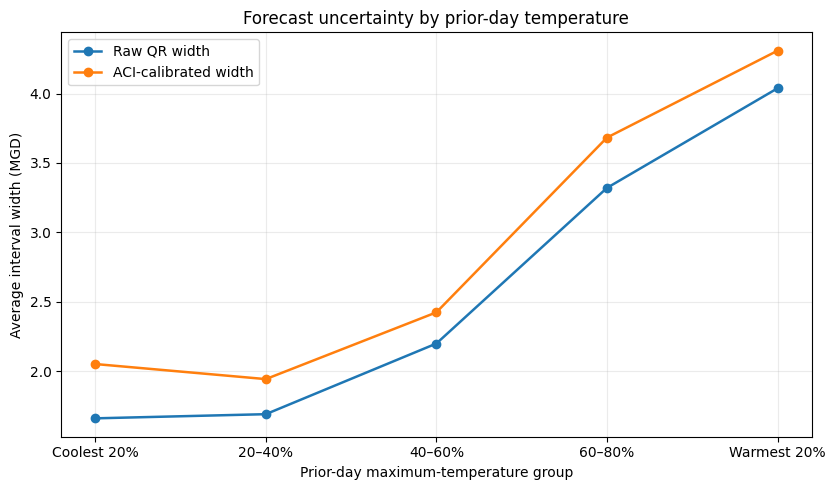

In [12]:
fig, ax = plt.subplots(figsize=(8.5, 5))

x = np.arange(len(temperature_summary))

ax.plot(
    x,
    temperature_summary["mean_raw_qr_width_mgd"],
    marker="o",
    linewidth=1.8,
    label="Raw QR width",
)

ax.plot(
    x,
    temperature_summary["mean_aci_width_mgd"],
    marker="o",
    linewidth=1.8,
    label="ACI-calibrated width",
)

ax.set_title("Forecast uncertainty by prior-day temperature")
ax.set_xlabel("Prior-day maximum-temperature group")
ax.set_ylabel("Average interval width (MGD)")
ax.set_xticks(x)
ax.set_xticklabels(temperature_summary["temperature_group"])
ax.grid(alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()

### Warmer conditions are associated with both higher demand and greater uncertainty

The relationship between prior-day temperature and the forecast distribution becomes
especially pronounced in the warmer half of the data.

Median predicted demand is approximately 14-15 MGD through the first three
temperature groups, then increases to about 22.7 MGD in the 60-80% group and
30.4 MGD in the warmest quintile.

Forecast uncertainty changes at the same time. The raw 10th-to-90th percentile QR
width rises from about 1.66 MGD in the coolest quintile to 4.04 MGD in
the warmest quintile. After ACI calibration, average width rises from approximately
2.05 to 4.31 MGD.

The similarity between the raw-QR and ACI-calibrated trajectories is important.
The weather-associated change in uncertainty is already present in the conditional
quantile forecasts; ACI mainly shifts those intervals to improve sequential calibration.

These results extend the earlier point-forecasting analysis. Weather is associated not
only with the predicted level of water demand, but also with how precisely that demand
can be forecast.

### A smaller precipitation diagnostic

Prior-day precipitation provides a second, simpler weather regime.

We compare days following measurable precipitation with days following no recorded precipitation. Because the groups may be quite unequal in size, this result should be interpreted as descriptive context rather than given the same weight as the temperature-quintile analysis.

In [13]:
analysis["prior_day_wet"] = np.where(
    analysis["prior_day_precipitation_in"] > 0,
    "Wet prior day",
    "Dry prior day",
)

precipitation_summary = (
    analysis
    .groupby("prior_day_wet", observed=True)
    .agg(
        n_observations=("date", "size"),
        median_predicted_demand_mgd=("q50", "median"),
        mean_raw_qr_width_mgd=("raw_qr_width", "mean"),
        mean_aci_width_mgd=("aci_width", "mean"),
        coverage_80=("covered", "mean"),
        lower_miss_rate=("lower_miss", "mean"),
        upper_miss_rate=("upper_miss", "mean"),
    )
    .reset_index()
)

display(precipitation_summary.round(4))

,prior_day_wet,n_observations,median_predicted_demand_mgd,mean_raw_qr_width_mgd,mean_aci_width_mgd,coverage_80,lower_miss_rate,upper_miss_rate
0,Dry prior day,636,15.1525,2.4450,2.7328,0.8286,0.0959,0.0755
1,Wet prior day,185,18.6038,3.0433,3.3872,0.7297,0.1081,0.1622


### Prior-day precipitation identifies a second difficult forecast regime

Days following measurable precipitation have wider forecast distributions than days
following no recorded precipitation. Their average raw QR width is about 3.04 MGD
versus 2.45 MGD on dry-prior-day forecasts, and their calibrated width is about
3.39 versus 2.73 MGD.

Calibration is also substantially weaker in the wet-prior-day group: empirical coverage
is approximately 73.0%, compared with 82.9% following dry days. Most of the
difference comes from upper-tail misses, which occur on about 16.2%*of wet-prior-day
forecasts.

This comparison should not be interpreted as evidence that precipitation itself increases
water demand or forecast uncertainty. The wet and dry groups can differ in season,
temperature, and other conditions. Instead, prior-day precipitation appears to identify
a subset of forecasts for which the current model is less well calibrated.

## 4. Is uncertainty symmetric around the predicted median?

The central QR band need not place the same amount of uncertainty above and below the predicted median.

Define

$$
L_t
=
\widehat q_{.50,t}
-
\widehat q_{.10,t},
$$

and

$$
U_t
=
\widehat q_{.90,t}
-
\widehat q_{.50,t}.
$$

If $U_t>L_t$, the estimated conditional distribution has more spread toward unusually high demand. If $L_t>U_t$, the larger spread is toward unexpectedly low demand.

We again examine these quantities across prior-day temperature groups.

In [14]:
tail_spread_summary = (
    analysis
    .groupby("temperature_group", observed=True)
    .agg(
        n_observations=("date", "size"),
        mean_lower_spread_mgd=("lower_qr_spread", "mean"),
        mean_upper_spread_mgd=("upper_qr_spread", "mean"),
        mean_upper_minus_lower_mgd=("spread_asymmetry", "mean"),
        median_upper_minus_lower_mgd=("spread_asymmetry", "median"),
    )
    .reset_index()
)

display(tail_spread_summary.round(4))

,temperature_group,n_observations,mean_lower_spread_mgd,mean_upper_spread_mgd,mean_upper_minus_lower_mgd,median_upper_minus_lower_mgd
0,Coolest 20%,165,0.8671,0.7923,-0.0747,0.0014
1,20–40%,164,0.8379,0.8515,0.0136,0.0443
2,40–60%,164,1.1192,1.0793,-0.0399,-0.0116
3,60–80%,164,1.8906,1.4292,-0.4615,-0.3120
4,Warmest 20%,164,2.4774,1.5601,-0.9172,-0.9013


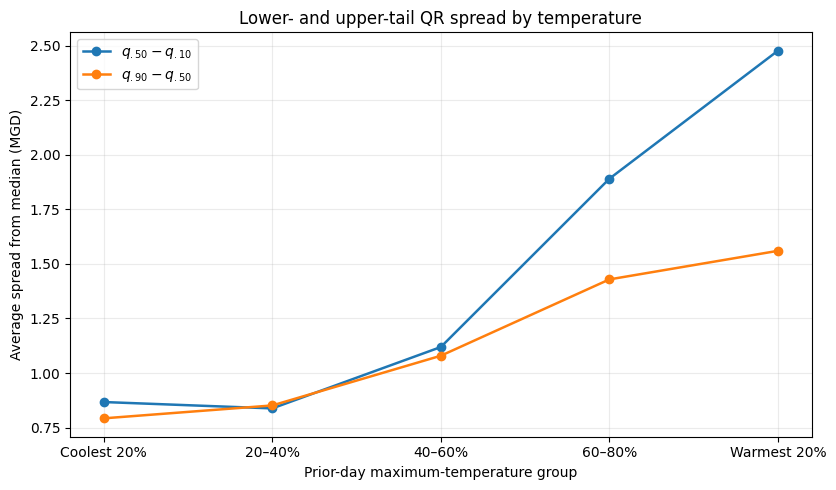

In [15]:
fig, ax = plt.subplots(figsize=(8.5, 5))

x = np.arange(len(tail_spread_summary))

ax.plot(
    x,
    tail_spread_summary["mean_lower_spread_mgd"],
    marker="o",
    linewidth=1.8,
    label=r"$q_{.50}-q_{.10}$",
)

ax.plot(
    x,
    tail_spread_summary["mean_upper_spread_mgd"],
    marker="o",
    linewidth=1.8,
    label=r"$q_{.90}-q_{.50}$",
)

ax.set_title("Lower- and upper-tail QR spread by temperature")
ax.set_xlabel("Prior-day maximum-temperature group")
ax.set_ylabel("Average spread from median (MGD)")
ax.set_xticks(x)
ax.set_xticklabels(tail_spread_summary["temperature_group"])
ax.grid(alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()

### Warm-weather uncertainty is increasingly concentrated below the median forecast

The widening of the QR distribution is not symmetric.

For cool and moderate temperature groups, the distance from the predicted median to
the 10th and 90th percentiles is similar. The two sides begin to separate markedly in
warmer conditions.

In the warmest temperature quintile, the average lower spread,

$$
q_{.50}-q_{.10},
$$

is approximately 2.48 MGD, while the upper spread,

$$
q_{.90}-q_{.50},
$$

is only about 1.56 MGD. The average difference between upper- and lower-tail
spread is therefore approximately -0.92 MGD.

Thus, although warm conditions are associated with high predicted demand, the estimated
conditional distribution allows considerably more room for demand to fall below that
high median forecast than to rise still farther above it.

This asymmetry is a feature of the QR forecast distribution itself rather than something
introduced by the two-sided ACI calibration.

## 5. What does ACI add beyond the conditional QR band?

ACI does not refit the QR model or directly model weather. Its contribution comes from recent forecast errors.

A useful diagnostic is therefore to compare how strongly weather and expected demand are associated with:

- the **raw QR width**, and
- the **ACI correction**.

The correlations below are descriptive Spearman rank correlations. They are not used for model fitting and should not be interpreted causally.

In [16]:
correlation_variables = {
    "Prior-day max temperature": "prior_day_tmax_f",
    "Predicted median demand": "q50",
    "Observed demand": "y_true",
}

correlation_rows = []

for label, column in correlation_variables.items():
    correlation_rows.append(
        {
            "variable": label,
            "spearman_with_raw_qr_width": analysis[column].corr(
                analysis["raw_qr_width"],
                method="spearman",
            ),
            "spearman_with_aci_correction": analysis[column].corr(
                analysis["aci_one_sided_correction"],
                method="spearman",
            ),
            "spearman_with_final_aci_width": analysis[column].corr(
                analysis["aci_width"],
                method="spearman",
            ),
        }
    )

correlation_summary = pd.DataFrame(correlation_rows)

display(correlation_summary.round(4))

,variable,spearman_with_raw_qr_width,spearman_with_aci_correction,spearman_with_final_aci_width
0,Prior-day max temperature,0.6673,-0.2083,0.6331
1,Predicted median demand,0.7084,-0.1759,0.7051
2,Observed demand,0.6889,-0.1903,0.6816


### Conditional QR, rather than ACI, drives the weather-dependent uncertainty pattern

The rank correlations reinforce the decomposition of the final interval.

Prior-day maximum temperature has a Spearman correlation of approximately 0.67
with raw QR width and 0.63 with final calibrated width. Predicted median demand
is even more strongly associated with both, with correlations of approximately
0.71.

By contrast, the ACI correction has only weak negative rank associations with
temperature, predicted demand, and observed demand, ranging from approximately
-0.18 to -0.21.

The final interval therefore inherits most of its regime-specific structure from the
conditional QR model. ACI is not learning a separate rule such as "hot days require
wider intervals." Instead, it responds to the recent sequence of conformity errors and
makes a comparatively modest calibration adjustment to a distribution whose width is
already weather and demand dependent.

## 6. Where does calibration still struggle?

Notebook 04 showed that pooled coverage near 80% does not imply uniform performance across all conditions.

Here we examine ACI coverage across two operationally interpretable regimes:

1. prior-day temperature quintiles;
2. predicted-median-demand quintiles.

The second analysis is useful because it asks whether the calibrated system behaves differently when it is itself forecasting unusually high demand.

In [17]:
coverage_by_temperature = (
    analysis
    .groupby("temperature_group", observed=True)
    .agg(
        n_observations=("date", "size"),
        coverage_80=("covered", "mean"),
        average_width_mgd=("aci_width", "mean"),
        lower_miss_rate=("lower_miss", "mean"),
        upper_miss_rate=("upper_miss", "mean"),
    )
    .reset_index()
)

display(coverage_by_temperature.round(4))

,temperature_group,n_observations,coverage_80,average_width_mgd,lower_miss_rate,upper_miss_rate
0,Coolest 20%,165,0.8182,2.0507,0.0848,0.0970
1,20–40%,164,0.7744,1.9421,0.0732,0.1524
2,40–60%,164,0.8415,2.4232,0.1159,0.0427
3,60–80%,164,0.7866,3.6822,0.1402,0.0732
4,Warmest 20%,164,0.8110,4.3083,0.0793,0.1098


In [18]:
analysis["predicted_demand_group"] = pd.qcut(
    analysis["q50"].rank(method="first"),
    q=5,
    labels=DEMAND_GROUP_LABELS,
)

coverage_by_predicted_demand = (
    analysis
    .groupby("predicted_demand_group", observed=True)
    .agg(
        n_observations=("date", "size"),
        median_predicted_demand_mgd=("q50", "median"),
        coverage_80=("covered", "mean"),
        average_width_mgd=("aci_width", "mean"),
        lower_miss_rate=("lower_miss", "mean"),
        upper_miss_rate=("upper_miss", "mean"),
    )
    .reset_index()
)

display(coverage_by_predicted_demand.round(4))

,predicted_demand_group,n_observations,median_predicted_demand_mgd,coverage_80,average_width_mgd,lower_miss_rate,upper_miss_rate
0,Lowest 20%,165,13.3853,0.7818,1.9747,0.0182,0.2000
1,20–40%,164,14.2381,0.8902,1.8352,0.0793,0.0305
2,40–60%,164,15.3451,0.8110,2.2311,0.1220,0.0671
3,60–80%,164,22.6592,0.7561,3.8178,0.1707,0.0732
4,Highest 20%,164,30.7576,0.7927,4.5481,0.1037,0.1037


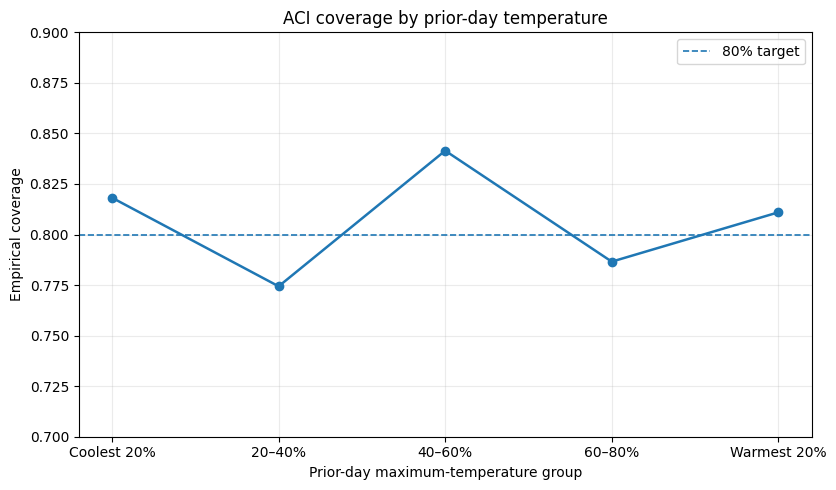

In [19]:
fig, ax = plt.subplots(figsize=(8.5, 5))

x = np.arange(len(coverage_by_temperature))

ax.plot(
    x,
    coverage_by_temperature["coverage_80"],
    marker="o",
    linewidth=1.8,
)

ax.axhline(
    0.80,
    linestyle="--",
    linewidth=1.2,
    label="80% target",
)

ax.set_ylim(0.70, 0.90)
ax.set_title("ACI coverage by prior-day temperature")
ax.set_xlabel("Prior-day maximum-temperature group")
ax.set_ylabel("Empirical coverage")
ax.set_xticks(x)
ax.set_xticklabels(coverage_by_temperature["temperature_group"])
ax.grid(alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()

### Remaining calibration error is not concentrated only on the hottest or highest-demand days

The regime analysis complicates a simple interpretation of summer undercoverage.

Coverage does vary across temperature groups, but the warmest quintile itself is
well calibrated at approximately 81.1%. The largest temperature-group deviations
occur in the 20-40% group, with about 77.4% coverage, and the 60-80% group,
with about 78.7%.

The direction of the errors also changes across regimes. The 20-40% temperature
group misses disproportionately above the interval, whereas the 60-80% group has
more observations below the lower endpoint.

A similar non-monotone pattern appears when forecasts are grouped by predicted demand.
The highest-demand quintile achieves approximately 79.3% coverage, with nearly
equal lower- and upper-tail miss rates. In contrast, the 60-80% predicted-demand
group covers only about 75.6% of observations, with most misses occurring below
the interval.

At the low-demand end, coverage is about 78.2%, but the errors are strongly
one-sided: approximately 20% of observations exceed the upper endpoint.

The remaining calibration weakness therefore cannot be summarized as simply
"high demand is harder to forecast." It appears more strongly in particular intermediate
regimes and in the direction of the forecast error.

## 7. What characterizes high-uncertainty forecast days?

The final analysis takes the forecasting system at face value.

We define a **high-uncertainty day** as a date whose calibrated interval width lies in the widest 10% of all evaluation-period intervals.

We then compare those days with the remaining 90% in terms of:

- prior-day temperature and precipitation;
- predicted median demand;
- observed demand;
- raw QR width;
- ACI correction;
- empirical coverage.

This asks a practical question:

> **What does a day look like when the forecasting system is telling us that tomorrow's demand is unusually difficult to pin down?**

In [20]:
high_uncertainty_threshold = analysis["aci_width"].quantile(0.90)

analysis["uncertainty_group"] = np.where(
    analysis["aci_width"] >= high_uncertainty_threshold,
    "Widest 10%",
    "Remaining 90%",
)

high_uncertainty_summary = (
    analysis
    .groupby("uncertainty_group", observed=True)
    .agg(
        n_observations=("date", "size"),
        mean_prior_day_tmax_f=("prior_day_tmax_f", "mean"),
        median_prior_day_precipitation_in=("prior_day_precipitation_in", "median"),
        wet_prior_day_rate=(
            "prior_day_wet",
            lambda s: np.mean(s == "Wet prior day"),
        ),
        median_predicted_demand_mgd=("q50", "median"),
        median_observed_demand_mgd=("y_true", "median"),
        mean_raw_qr_width_mgd=("raw_qr_width", "mean"),
        mean_aci_correction_mgd=("aci_one_sided_correction", "mean"),
        mean_final_width_mgd=("aci_width", "mean"),
        coverage_80=("covered", "mean"),
    )
    .reset_index()
)

display(high_uncertainty_summary.round(4))

,uncertainty_group,n_observations,mean_prior_day_tmax_f,median_prior_day_precipitation_in,wet_prior_day_rate,median_predicted_demand_mgd,median_observed_demand_mgd,mean_raw_qr_width_mgd,mean_aci_correction_mgd,mean_final_width_mgd,coverage_80
0,Remaining 90%,738,62.1572,0.0,0.1978,14.9288,14.845,2.2663,0.1379,2.5422,0.7995
1,Widest 10%,83,82.5422,0.0,0.4699,29.2305,28.210,5.3671,0.2598,5.8867,0.8675


In [21]:
def season_from_month(month):
    if month in (12, 1, 2):
        return "Winter"
    if month in (3, 4, 5):
        return "Spring"
    if month in (6, 7, 8):
        return "Summer"
    return "Fall"

analysis["season"] = analysis["date"].dt.month.map(season_from_month)

high_uncertainty_seasons = (
    analysis.loc[analysis["uncertainty_group"] == "Widest 10%"]
    .groupby("season", observed=True)
    .size()
    .rename("n_days")
    .reset_index()
)

high_uncertainty_seasons["share_of_high_uncertainty_days"] = (
    high_uncertainty_seasons["n_days"]
    / high_uncertainty_seasons["n_days"].sum()
)

display(high_uncertainty_seasons.round(4))

,season,n_days,share_of_high_uncertainty_days
0,Fall,9,0.1084
1,Spring,11,0.1325
2,Summer,62,0.7470
3,Winter,1,0.0120


In [22]:
widest_days = (
    analysis
    .sort_values("aci_width", ascending=False)
    [
        [
            "date",
            "prior_day_tmax_f",
            "prior_day_precipitation_in",
            "q50",
            "y_true",
            "raw_qr_width",
            "aci_one_sided_correction",
            "aci_width",
            "covered",
        ]
    ]
    .head(15)
    .reset_index(drop=True)
)

display(widest_days.round(4))

,date,prior_day_tmax_f,prior_day_precipitation_in,q50,y_true,raw_qr_width,aci_one_sided_correction,aci_width,covered
0,2023-09-04,87.0,0.02,25.3052,26.51,6.9139,0.4414,7.7967,True
1,2023-07-03,90.0,0.00,28.6818,29.60,5.9352,0.8512,7.6376,True
2,2024-06-19,84.0,0.00,34.1379,33.53,7.5409,-0.0573,7.4263,True
3,2023-07-04,91.0,0.02,29.2305,24.94,5.5970,0.8512,7.2995,True
4,2023-07-16,83.0,0.01,30.2218,29.97,6.1599,0.5651,7.2901,True
5,2023-07-14,92.0,0.00,30.8864,31.84,6.0480,0.6091,7.2661,True
6,2023-07-07,71.0,0.25,23.8263,23.18,5.4193,0.9023,7.2240,True
7,2023-07-05,83.0,0.34,29.0261,22.58,5.7432,0.7171,7.1773,False
8,2023-07-15,82.0,0.00,30.6456,30.36,5.9886,0.5651,7.1189,True
9,2023-07-13,91.0,0.00,30.0484,30.30,5.7164,0.6593,7.0350,True


The individual widest-interval forecasts reinforce the aggregate profile. Most occur
during July 2023 or the warm season of 2024, generally following warm prior days and
with predicted demand in the mid-20s to low-30s MGD.

Fourteen of the 15 widest intervals contain the observed demand. The largest intervals
therefore appear primarily to reflect recognized forecast uncertainty rather than a set
of repeated catastrophic misses.

### The widest intervals identify a coherent high-demand summer regime

The widest 10% of calibrated intervals are not distributed randomly across the
evaluation period.

These high-uncertainty forecasts follow substantially warmer days: average prior-day
maximum temperature is approximately 82.5°F, compared with 62.2°F for
the remaining forecasts. Their median predicted demand is about 29.2 MGD, nearly
twice the 14.9 MGD median for the remaining 90%.

They are also strongly seasonal. Approximately 75% of the widest intervals occur
during summer, while only one occurs during winter.

Most of the additional width is already present before conformal calibration. Raw QR
width averages about 5.37 MGD for the widest 10% of forecasts, compared with
2.27 MGD for the remaining observations. The ACI correction is also larger on
these days, but the difference is much smaller. This again indicates that QR is doing
most of the work of identifying difficult forecast conditions.

The calibrated system is not simply failing on these high-uncertainty days. Their
empirical coverage is approximately 86.7%, higher than for the remaining forecasts.
The system generally responds to the more difficult regime by issuing wider intervals.

Prior-day precipitation is also more common among the widest intervals: about 47%
follow a wet day compared with roughly 20% of the remaining forecasts. Because
temperature, season, demand, and precipitation are related, this should be viewed as a
descriptive characteristic of the regime rather than an isolated precipitation effect.

## 8. Final out-of-sample probabilistic evaluation

The preceding sections interpret the selected probabilistic forecasting system
using the chronological 2023–March 2025 evaluation period. We now ask whether
that fixed system generalizes to the subsequent April 2025–March 2026 year.

All probabilistic modeling choices are frozen before this evaluation. The final
system uses:

- Matrix B;
- linear quantile regression at the 0.10, 0.50 and 0.90 quantiles;
- two-sided Adaptive Conformal Inference (ACI);
- a 180-day conformity-score history; and
- the previously selected ACI adaptation rate.

The three quantile-regression models are fitted once using all eligible
observations through March 31, 2025 and are then held fixed throughout the
365-day evaluation period.

ACI is initialized using only chronologically valid pre-holdout forecast errors.
Within the evaluation year it operates prequentially: the interval for day
$t$ is constructed using only information available before the outcome on
day $t$ is observed. That outcome is incorporated only afterward, when
updating the calibration state for day $t+1$.

Because this calendar period has already been examined in the earlier
point-forecasting analysis, it is described here as a **final out-of-sample
probabilistic evaluation** rather than as a newly untouched holdout. No
probabilistic model, calibration method, window length or adaptation parameter
will be changed in response to the results below.

In [23]:
# Frozen probabilistic specification
FEATURE_MATRIX = "B"

LOWER_TAU = 0.10
MEDIAN_TAU = 0.50
UPPER_TAU = 0.90
QUANTILES = (LOWER_TAU, MEDIAN_TAU, UPPER_TAU)

TARGET_COVERAGE = 0.80
TARGET_MISCOVERAGE = 1.0 - TARGET_COVERAGE

ACI_WINDOW = 180
ACI_GAMMA = 0.02

FINAL_TRAIN_END = pd.Timestamp("2025-03-31")
HOLDOUT_START = pd.Timestamp("2025-04-01")
HOLDOUT_END = pd.Timestamp("2026-03-31")


# Rebuild the complete leakage-safe feature table.
feature_set = load_and_build_forecasting_features(DATA_PATH)

holdout_dates_all = pd.to_datetime(
    feature_set.dates
).reset_index(drop=True)

holdout_y_all = feature_set.target.to_numpy(dtype=float)
holdout_X_df_all = feature_set.matrix_b.copy()
holdout_X_all = holdout_X_df_all.to_numpy(dtype=float)


# Define the fixed training sample and final evaluation year.
final_train_mask = (
    holdout_dates_all <= FINAL_TRAIN_END
)

final_holdout_mask = holdout_dates_all.between(
    HOLDOUT_START,
    HOLDOUT_END,
    inclusive="both",
)

final_train_idx = np.flatnonzero(
    final_train_mask.to_numpy()
)

final_holdout_idx = np.flatnonzero(
    final_holdout_mask.to_numpy()
)


# Basic chronological and integrity checks.
assert len(holdout_dates_all) == len(holdout_y_all) == len(holdout_X_df_all)
assert holdout_dates_all.is_monotonic_increasing
assert holdout_dates_all.is_unique

assert np.isfinite(holdout_X_all).all()
assert np.isfinite(holdout_y_all).all()

assert (
    holdout_dates_all.iloc[final_train_idx].max()
    == FINAL_TRAIN_END
)

assert (
    holdout_dates_all.iloc[final_holdout_idx].min()
    == HOLDOUT_START
)

assert (
    holdout_dates_all.iloc[final_holdout_idx].max()
    == HOLDOUT_END
)

assert (
    holdout_dates_all.iloc[final_train_idx].max()
    < holdout_dates_all.iloc[final_holdout_idx].min()
)

assert len(final_train_idx) == 1889
assert len(final_holdout_idx) == 365
assert holdout_X_all.shape[1] == 54


boundary_summary = pd.DataFrame(
    [
        {
            "period": "Final QR training sample",
            "start": holdout_dates_all.iloc[final_train_idx].min(),
            "end": holdout_dates_all.iloc[final_train_idx].max(),
            "observations": len(final_train_idx),
        },
        {
            "period": "Final probabilistic evaluation",
            "start": holdout_dates_all.iloc[final_holdout_idx].min(),
            "end": holdout_dates_all.iloc[final_holdout_idx].max(),
            "observations": len(final_holdout_idx),
        },
    ]
)

display(boundary_summary)

print("Feature matrix:", FEATURE_MATRIX)
print("Predictors:", holdout_X_all.shape[1])
print("Quantiles:", QUANTILES)
print("Target coverage:", TARGET_COVERAGE)
print("ACI window:", ACI_WINDOW, "days")
print("ACI gamma:", ACI_GAMMA)
print("\nFinal evaluation boundary checks passed.")

,period,start,end,observations
0,Final QR training sample,2020-01-29,2025-03-31,1889
1,Final probabilistic evaluation,2025-04-01,2026-03-31,365


Feature matrix: B
Predictors: 54
Quantiles: (0.1, 0.5, 0.9)
Target coverage: 0.8
ACI window: 180 days
ACI gamma: 0.02

Final evaluation boundary checks passed.


### Generate the fixed raw quantile forecasts

With the evaluation boundary verified, the three linear quantile-regression models are fitted once using all eligible observations through March 31, 2025. These fitted models are then held fixed while generating the 0.10, 0.50 and 0.90 quantile forecasts for the subsequent 365-day evaluation period.

In [24]:
def make_linear_quantile_model(tau: float) -> Pipeline:
    """Match the Linear QR specification used in Notebook 03."""
    return Pipeline(
        [
            ("scale", StandardScaler()),
            (
                "quantile",
                QuantileRegressor(
                    quantile=tau,
                    alpha=0.0,
                    solver="highs",
                    fit_intercept=True,
                ),
            ),
        ]
    )


# Fixed pre-holdout training and final evaluation samples.
X_final_train = holdout_X_all[final_train_idx]
y_final_train = holdout_y_all[final_train_idx]

X_final_holdout = holdout_X_all[final_holdout_idx]
y_final_holdout = holdout_y_all[final_holdout_idx]

dates_final_holdout = (
    holdout_dates_all
    .iloc[final_holdout_idx]
    .reset_index(drop=True)
)


# Fit each quantile model once using all eligible data through 2025-03-31.
final_qr_models = {}
final_qr_predictions = {}
final_qr_fit_rows = []

for tau in QUANTILES:
    model = make_linear_quantile_model(tau)

    start = perf_counter()
    model.fit(X_final_train, y_final_train)
    fit_seconds = perf_counter() - start

    prediction = np.asarray(
        model.predict(X_final_holdout),
        dtype=float,
    ).ravel()

    final_qr_models[tau] = model
    final_qr_predictions[tau] = prediction

    final_qr_fit_rows.append(
        {
            "tau": tau,
            "n_train": len(X_final_train),
            "n_holdout": len(X_final_holdout),
            "fit_seconds": fit_seconds,
        }
    )


final_qr_fit_summary = pd.DataFrame(final_qr_fit_rows)

final_qr_holdout = pd.DataFrame(
    {
        "date": dates_final_holdout,
        "y_true": y_final_holdout,
        "q10": final_qr_predictions[LOWER_TAU],
        "q50": final_qr_predictions[MEDIAN_TAU],
        "q90": final_qr_predictions[UPPER_TAU],
    }
)


# Structural checks only — no calibration yet.
assert len(final_qr_holdout) == 365
assert final_qr_holdout["date"].is_monotonic_increasing
assert final_qr_holdout["date"].is_unique

assert final_qr_holdout[
    ["y_true", "q10", "q50", "q90"]
].notna().all().all()

assert np.isfinite(
    final_qr_holdout[
        ["y_true", "q10", "q50", "q90"]
    ].to_numpy()
).all()


display(final_qr_fit_summary.round(4))
display(final_qr_holdout.head())

print(
    "Forecast range:",
    final_qr_holdout["date"].min().date(),
    "through",
    final_qr_holdout["date"].max().date(),
)

print(
    "Quantile models were fit once on",
    len(X_final_train),
    "pre-holdout observations.",
)

print(
    "Final raw QR forecasts generated:",
    len(final_qr_holdout),
)

,tau,n_train,n_holdout,fit_seconds
0,0.1,1889,365,0.8135
1,0.5,1889,365,0.8188
2,0.9,1889,365,0.7596


,date,y_true,q10,q50,q90
0,2025-04-01,14.44,13.276450,14.038938,14.548335
1,2025-04-02,13.29,13.963450,14.740376,15.532191
2,2025-04-03,13.74,12.491530,13.787053,14.441098
3,2025-04-04,13.74,12.825710,13.295153,14.076185
4,2025-04-05,13.55,12.415352,13.467583,14.124668


Forecast range: 2025-04-01 through 2026-03-31
Quantile models were fit once on 1889 pre-holdout observations.
Final raw QR forecasts generated: 365


In [25]:
def summarize_raw_qr_holdout(frame: pd.DataFrame) -> pd.DataFrame:
    y_true = frame["y_true"].to_numpy(dtype=float)
    lower = frame["q10"].to_numpy(dtype=float)
    median = frame["q50"].to_numpy(dtype=float)
    upper = frame["q90"].to_numpy(dtype=float)

    covered = (y_true >= lower) & (y_true <= upper)
    lower_miss = y_true < lower
    upper_miss = y_true > upper
    crossed = lower > upper
    width = upper - lower

    return pd.DataFrame(
        [
            {
                "method": "Raw Linear QR",
                "n_observations": len(frame),
                "coverage_80": covered.mean(),
                "average_width": width.mean(),
                "median_width": np.median(width),
                "lower_miss_rate": lower_miss.mean(),
                "upper_miss_rate": upper_miss.mean(),
                "crossing_rate": crossed.mean(),
                "pinball_q10": mean_pinball_loss(
                    y_true,
                    lower,
                    alpha=LOWER_TAU,
                ),
                "pinball_q50": mean_pinball_loss(
                    y_true,
                    median,
                    alpha=MEDIAN_TAU,
                ),
                "pinball_q90": mean_pinball_loss(
                    y_true,
                    upper,
                    alpha=UPPER_TAU,
                ),
            }
        ]
    )


final_raw_qr_summary = summarize_raw_qr_holdout(
    final_qr_holdout
)

display(
    final_raw_qr_summary.round(5)
)


print(
    "Nominal central coverage:",
    f"{TARGET_COVERAGE:.1%}",
)

print(
    "Observed raw QR coverage:",
    f"{final_raw_qr_summary.loc[0, 'coverage_80']:.1%}",
)

print(
    "Coverage error:",
    f"{final_raw_qr_summary.loc[0, 'coverage_80'] - TARGET_COVERAGE:+.1%}",
)

print(
    "Lower-tail miss rate:",
    f"{final_raw_qr_summary.loc[0, 'lower_miss_rate']:.1%}",
)

print(
    "Upper-tail miss rate:",
    f"{final_raw_qr_summary.loc[0, 'upper_miss_rate']:.1%}",
)

,method,n_observations,coverage_80,average_width,median_width,lower_miss_rate,upper_miss_rate,crossing_rate,pinball_q10,pinball_q50,pinball_q90
0,Raw Linear QR,365,0.71781,2.70855,2.41046,0.14521,0.13699,0.0,0.23424,0.50296,0.2311


Nominal central coverage: 80.0%
Observed raw QR coverage: 71.8%
Coverage error: -8.2%
Lower-tail miss rate: 14.5%
Upper-tail miss rate: 13.7%


### The raw quantile interval under-covers on the final year

The nominal 80% raw QR interval covered only 71.8% of observations. Misses were relatively balanced between the lower and upper tails (14.5% and 13.7%), suggesting that the main issue is general undercoverage rather than a strongly directional error.

This provides the baseline against which the previously selected ACI procedure is evaluated.

### Continue ACI from its pre-evaluation state

The selected ACI system is not restarted on April 1, 2025. Its controller state and trailing 180 conformity scores are reconstructed from the chronologically valid pre-evaluation forecasts, so the final evaluation represents a continuous sequential deployment of the previously selected procedure.

In [26]:
required_aci_columns = {
    "date",
    "y_true",
    "q10",
    "q50",
    "q90",
    "lower",
    "upper",
    "alpha_t",
}

missing_aci_columns = (
    required_aci_columns
    - set(aci.columns)
)

assert not missing_aci_columns, (
    f"Missing required ACI columns: {sorted(missing_aci_columns)}"
)

aci_preholdout = (
    aci
    .sort_values("date")
    .reset_index(drop=True)
    .copy()
)

assert aci_preholdout["date"].iloc[-1] == FINAL_TRAIN_END


# Reconstruct the raw two-sided CQR conformity scores.
aci_preholdout["score_two_sided"] = np.maximum(
    aci_preholdout["q10"] - aci_preholdout["y_true"],
    aci_preholdout["y_true"] - aci_preholdout["q90"],
)


# The saved alpha_t on 2025-03-31 is the value used to issue
# that day's interval. Apply the March 31 feedback update once
# to obtain the controller state entering 2025-04-01.
last_preholdout_row = aci_preholdout.iloc[-1]

last_preholdout_covered = bool(
    (last_preholdout_row["y_true"] >= last_preholdout_row["lower"])
    and
    (last_preholdout_row["y_true"] <= last_preholdout_row["upper"])
)

last_preholdout_error = (
    0.0 if last_preholdout_covered else 1.0
)

alpha_holdout_start = float(
    last_preholdout_row["alpha_t"]
    + ACI_GAMMA
    * (
        TARGET_MISCOVERAGE
        - last_preholdout_error
    )
)


# The score history entering April 1 contains the most recent
# 180 raw conformity scores, including March 31.
initial_aci_history = (
    aci_preholdout
    .tail(ACI_WINDOW)
    .copy()
)

initial_aci_scores = (
    initial_aci_history["score_two_sided"]
    .to_numpy(dtype=float)
)


# Integrity checks.
assert len(initial_aci_scores) == ACI_WINDOW
assert np.isfinite(initial_aci_scores).all()

assert initial_aci_history["date"].iloc[-1] == FINAL_TRAIN_END
assert initial_aci_history["date"].is_monotonic_increasing
assert initial_aci_history["date"].is_unique

assert np.isclose(
    alpha_holdout_start,
    0.244,
)


print(
    "Last pre-holdout date:",
    last_preholdout_row["date"].date(),
)

print(
    "alpha_t used on March 31:",
    round(float(last_preholdout_row["alpha_t"]), 6),
)

print(
    "March 31 interval covered:",
    last_preholdout_covered,
)

print(
    "alpha_t entering April 1:",
    round(alpha_holdout_start, 6),
)

print(
    "\nInitial ACI score-history length:",
    len(initial_aci_scores),
)

print(
    "Score-history range:",
    initial_aci_history["date"].iloc[0].date(),
    "through",
    initial_aci_history["date"].iloc[-1].date(),
)

print(
    "Most recent raw conformity score:",
    round(float(initial_aci_scores[-1]), 6),
)

print("\nACI holdout-entry state verified.")

Last pre-holdout date: 2025-03-31
alpha_t used on March 31: 0.24
March 31 interval covered: True
alpha_t entering April 1: 0.244

Initial ACI score-history length: 180
Score-history range: 2024-10-03 through 2025-03-31
Most recent raw conformity score: -1.230766

ACI holdout-entry state verified.


In [27]:
def empirical_higher_quantile(values, p):
    """Match the empirical quantile rule used in Notebook 04."""
    values = np.asarray(values, dtype=float)

    if values.size == 0:
        return np.nan
    if p <= 0:
        return -np.inf
    if p >= 1:
        return np.inf

    return float(
        np.quantile(
            values,
            p,
            method="higher",
        )
    )


def run_final_holdout_aci(
    frame,
    initial_scores,
    alpha_start,
    *,
    window=ACI_WINDOW,
    gamma=ACI_GAMMA,
):
    """
    Continue the frozen two-sided ACI system through the final
    out-of-sample probabilistic evaluation.

    Each day's interval is issued before that day's outcome is
    incorporated into either the score history or controller state.
    """
    history = deque(
        np.asarray(initial_scores, dtype=float)[-window:],
        maxlen=window,
    )

    alpha_t = float(alpha_start)
    rows = []

    for row in frame.itertuples(index=False):

        # Determine today's conformal correction using only past scores.
        if alpha_t <= 1.0 / (len(history) + 1.0):
            correction = np.inf
        else:
            correction = empirical_higher_quantile(
                history,
                1.0 - np.clip(alpha_t, 0.0, 1.0),
            )

        lower = row.q10 - correction
        upper = row.q90 + correction

        covered = bool(
            (row.y_true >= lower)
            and
            (row.y_true <= upper)
        )

        err = 0.0 if covered else 1.0

        # Raw CQR score for today's observation.
        score_two_sided = float(
            max(
                row.q10 - row.y_true,
                row.y_true - row.q90,
            )
        )

        rows.append(
            {
                "date": row.date,
                "y_true": row.y_true,
                "q10": row.q10,
                "q50": row.q50,
                "q90": row.q90,
                "lower": lower,
                "upper": upper,
                "correction": correction,
                "alpha_t": alpha_t,
                "covered": covered,
                "score_two_sided": score_two_sided,
                "method": "Two-sided ACI (180d)",
            }
        )

        # Only now may today's outcome affect tomorrow's interval.
        history.append(score_two_sided)

        alpha_t = (
            alpha_t
            + gamma
            * (
                TARGET_MISCOVERAGE
                - err
            )
        )

    return pd.DataFrame(rows), alpha_t


final_aci_holdout, alpha_after_holdout = run_final_holdout_aci(
    final_qr_holdout,
    initial_aci_scores,
    alpha_holdout_start,
)


# Structural checks.
assert len(final_aci_holdout) == 365

assert (
    final_aci_holdout["date"].iloc[0]
    == HOLDOUT_START
)

assert (
    final_aci_holdout["date"].iloc[-1]
    == HOLDOUT_END
)

assert final_aci_holdout["date"].is_monotonic_increasing
assert final_aci_holdout["date"].is_unique

assert np.isclose(
    final_aci_holdout["alpha_t"].iloc[0],
    alpha_holdout_start,
)


display(
    final_aci_holdout[
        [
            "date",
            "y_true",
            "q10",
            "q90",
            "lower",
            "upper",
            "correction",
            "alpha_t",
            "covered",
        ]
    ].head()
)


print(
    "First holdout alpha_t:",
    round(
        float(final_aci_holdout["alpha_t"].iloc[0]),
        6,
    ),
)

print(
    "Final issued alpha_t:",
    round(
        float(final_aci_holdout["alpha_t"].iloc[-1]),
        6,
    ),
)

print(
    "Controller state after March 31, 2026:",
    round(float(alpha_after_holdout), 6),
)

print(
    "Finite interval fraction:",
    f"{np.mean(np.isfinite(final_aci_holdout['lower']) & np.isfinite(final_aci_holdout['upper'])):.3f}",
)

print(
    "Final ACI intervals generated:",
    len(final_aci_holdout),
)

,date,y_true,q10,q90,lower,upper,correction,alpha_t,covered
0,2025-04-01,14.44,13.276450,14.548335,13.261017,14.563769,0.015434,0.244,True
1,2025-04-02,13.29,13.963450,15.532191,13.975213,15.520428,-0.011763,0.248,False
2,2025-04-03,13.74,12.491530,14.441098,12.470983,14.461645,0.020547,0.232,True
3,2025-04-04,13.74,12.825710,14.076185,12.806048,14.095847,0.019662,0.236,True
4,2025-04-05,13.55,12.415352,14.124668,12.397207,14.142813,0.018146,0.240,True


First holdout alpha_t: 0.244
Final issued alpha_t: 0.14
Controller state after March 31, 2026: 0.144
Finite interval fraction: 1.000
Final ACI intervals generated: 365


In [28]:
def summarize_interval_forecasts(
    frame: pd.DataFrame,
    *,
    method: str,
    lower_col: str,
    upper_col: str,
) -> pd.DataFrame:
    y_true = frame["y_true"].to_numpy(dtype=float)
    lower = frame[lower_col].to_numpy(dtype=float)
    upper = frame[upper_col].to_numpy(dtype=float)

    covered = (y_true >= lower) & (y_true <= upper)
    lower_miss = y_true < lower
    upper_miss = y_true > upper
    crossed = lower > upper
    width = upper - lower

    return pd.DataFrame(
        [
            {
                "method": method,
                "n_observations": len(frame),
                "coverage_80": covered.mean(),
                "average_width": width.mean(),
                "median_width": np.median(width),
                "lower_miss_rate": lower_miss.mean(),
                "upper_miss_rate": upper_miss.mean(),
                "crossing_rate": crossed.mean(),
            }
        ]
    )


raw_holdout_interval_summary = summarize_interval_forecasts(
    final_qr_holdout,
    method="Raw Linear QR",
    lower_col="q10",
    upper_col="q90",
)

aci_holdout_interval_summary = summarize_interval_forecasts(
    final_aci_holdout,
    method="Two-sided ACI (180d)",
    lower_col="lower",
    upper_col="upper",
)

final_holdout_interval_summary = pd.concat(
    [
        raw_holdout_interval_summary,
        aci_holdout_interval_summary,
    ],
    ignore_index=True,
)

display(
    final_holdout_interval_summary.round(5)
)


# Compact comparison for interpretation.
raw_row = final_holdout_interval_summary.loc[
    final_holdout_interval_summary["method"] == "Raw Linear QR"
].iloc[0]

aci_row = final_holdout_interval_summary.loc[
    final_holdout_interval_summary["method"] == "Two-sided ACI (180d)"
].iloc[0]


coverage_gain_pp = 100 * (
    aci_row["coverage_80"]
    - raw_row["coverage_80"]
)

width_change_mgd = (
    aci_row["average_width"]
    - raw_row["average_width"]
)

width_change_pct = 100 * (
    aci_row["average_width"]
    / raw_row["average_width"]
    - 1.0
)


print(
    "Raw QR coverage:",
    f"{raw_row['coverage_80']:.1%}",
)

print(
    "ACI coverage:",
    f"{aci_row['coverage_80']:.1%}",
)

print(
    "Coverage change:",
    f"{coverage_gain_pp:+.1f} percentage points",
)

print(
    "\nRaw QR average width:",
    f"{raw_row['average_width']:.3f} MGD",
)

print(
    "ACI average width:",
    f"{aci_row['average_width']:.3f} MGD",
)

print(
    "Average-width change:",
    f"{width_change_mgd:+.3f} MGD",
    f"({width_change_pct:+.1f}%)",
)

print(
    "\nACI lower-tail miss rate:",
    f"{aci_row['lower_miss_rate']:.1%}",
)

print(
    "ACI upper-tail miss rate:",
    f"{aci_row['upper_miss_rate']:.1%}",
)

print(
    "ACI crossing rate:",
    f"{aci_row['crossing_rate']:.1%}",
)

,method,n_observations,coverage_80,average_width,median_width,lower_miss_rate,upper_miss_rate,crossing_rate
0,Raw Linear QR,365,0.71781,2.70855,2.41046,0.14521,0.13699,0.0
1,Two-sided ACI (180d),365,0.78630,3.00793,2.73989,0.10411,0.10959,0.0


Raw QR coverage: 71.8%
ACI coverage: 78.6%
Coverage change: +6.8 percentage points

Raw QR average width: 2.709 MGD
ACI average width: 3.008 MGD
Average-width change: +0.299 MGD (+11.1%)

ACI lower-tail miss rate: 10.4%
ACI upper-tail miss rate: 11.0%
ACI crossing rate: 0.0%


### ACI recovers most of the coverage gap with moderate widening

Sequential calibration increased coverage from 71.8% to 78.6%, a gain of 6.8 percentage points. Average interval width increased from 2.709 to 3.008 MGD, or about 11.1%.

The remaining errors were also well balanced: 10.4% of observations fell below the calibrated lower endpoint and 11.0% exceeded the upper endpoint. The improvement therefore reflects a relatively modest widening of the raw interval rather than an extreme inflation of uncertainty.

### Does calibration remain stable through the year?

Annual coverage can hide shorter periods of under- or overcoverage. The following diagnostics therefore examine 90-day rolling coverage and seasonal performance while leaving the sequential ACI controller unchanged.

In [29]:
# Build a temporal diagnostic table for the final evaluation year.

final_probabilistic_temporal = (
    final_aci_holdout[
        [
            "date",
            "y_true",
            "q10",
            "q50",
            "q90",
            "lower",
            "upper",
            "alpha_t",
            "correction",
        ]
    ]
    .copy()
)


final_probabilistic_temporal["raw_covered"] = (
    (final_probabilistic_temporal["y_true"]
     >= final_probabilistic_temporal["q10"])
    &
    (final_probabilistic_temporal["y_true"]
     <= final_probabilistic_temporal["q90"])
)

final_probabilistic_temporal["aci_covered"] = (
    (final_probabilistic_temporal["y_true"]
     >= final_probabilistic_temporal["lower"])
    &
    (final_probabilistic_temporal["y_true"]
     <= final_probabilistic_temporal["upper"])
)

final_probabilistic_temporal["raw_width"] = (
    final_probabilistic_temporal["q90"]
    - final_probabilistic_temporal["q10"]
)

final_probabilistic_temporal["aci_width"] = (
    final_probabilistic_temporal["upper"]
    - final_probabilistic_temporal["lower"]
)


ROLLING_WINDOW = 90

final_probabilistic_temporal["raw_coverage_90d"] = (
    final_probabilistic_temporal["raw_covered"]
    .astype(float)
    .rolling(
        ROLLING_WINDOW,
        min_periods=ROLLING_WINDOW,
    )
    .mean()
)

final_probabilistic_temporal["aci_coverage_90d"] = (
    final_probabilistic_temporal["aci_covered"]
    .astype(float)
    .rolling(
        ROLLING_WINDOW,
        min_periods=ROLLING_WINDOW,
    )
    .mean()
)

final_probabilistic_temporal["raw_width_90d"] = (
    final_probabilistic_temporal["raw_width"]
    .rolling(
        ROLLING_WINDOW,
        min_periods=ROLLING_WINDOW,
    )
    .mean()
)

final_probabilistic_temporal["aci_width_90d"] = (
    final_probabilistic_temporal["aci_width"]
    .rolling(
        ROLLING_WINDOW,
        min_periods=ROLLING_WINDOW,
    )
    .mean()
)


# Inspect approximately quarterly checkpoints.
checkpoint_dates = pd.to_datetime(
    [
        "2025-06-30",
        "2025-09-30",
        "2025-12-31",
        "2026-03-31",
    ]
)

rolling_checkpoints = (
    final_probabilistic_temporal[
        final_probabilistic_temporal["date"].isin(
            checkpoint_dates
        )
    ][
        [
            "date",
            "raw_coverage_90d",
            "aci_coverage_90d",
            "raw_width_90d",
            "aci_width_90d",
            "alpha_t",
        ]
    ]
    .reset_index(drop=True)
)

display(
    rolling_checkpoints.round(4)
)


valid_aci_rolling = (
    final_probabilistic_temporal["aci_coverage_90d"]
    .dropna()
)

print(
    "ACI 90-day rolling coverage range:",
    f"{valid_aci_rolling.min():.1%}",
    "to",
    f"{valid_aci_rolling.max():.1%}",
)

print(
    "Final 90-day ACI coverage:",
    f"{valid_aci_rolling.iloc[-1]:.1%}",
)

print(
    "Final 90-day raw QR coverage:",
    f"{final_probabilistic_temporal['raw_coverage_90d'].dropna().iloc[-1]:.1%}",
)

,date,raw_coverage_90d,aci_coverage_90d,raw_width_90d,aci_width_90d,alpha_t
0,2025-06-30,0.8111,0.8000,3.5365,3.3959,0.244
1,2025-09-30,0.7111,0.7556,3.9640,4.2273,0.152
2,2025-12-31,0.7000,0.8444,1.6411,2.2779,0.220
3,2026-03-31,0.6667,0.7556,1.6827,2.1243,0.140


ACI 90-day rolling coverage range: 73.3% to 85.6%
Final 90-day ACI coverage: 75.6%
Final 90-day raw QR coverage: 66.7%


In [30]:
season_order = [
    "Winter",
    "Spring",
    "Summer",
    "Fall",
]


final_holdout_seasonal = (
    final_aci_holdout
    .copy()
)

final_holdout_seasonal["season"] = (
    final_holdout_seasonal["date"]
    .dt.month
    .map(season_from_month)
)


season_rows = []

for season in season_order:
    season_df = final_holdout_seasonal.loc[
        final_holdout_seasonal["season"] == season
    ]

    raw_metrics = summarize_interval_forecasts(
        season_df,
        method="Raw Linear QR",
        lower_col="q10",
        upper_col="q90",
    ).iloc[0]

    aci_metrics = summarize_interval_forecasts(
        season_df,
        method="Two-sided ACI (180d)",
        lower_col="lower",
        upper_col="upper",
    ).iloc[0]

    season_rows.extend(
        [
            {
                "season": season,
                **raw_metrics.to_dict(),
            },
            {
                "season": season,
                **aci_metrics.to_dict(),
            },
        ]
    )


final_holdout_season_summary = pd.DataFrame(
    season_rows
)


display(
    final_holdout_season_summary[
        [
            "method",
            "season",
            "n_observations",
            "coverage_80",
            "average_width",
            "median_width",
            "lower_miss_rate",
            "upper_miss_rate",
        ]
    ].round(5)
)


# Put raw and calibrated results side-by-side for interpretation.
season_comparison = (
    final_holdout_season_summary
    .pivot(
        index="season",
        columns="method",
        values=[
            "coverage_80",
            "average_width",
        ],
    )
    .reindex(season_order)
)

season_comparison[
    ("coverage_gain_pp", "ACI minus raw")
] = 100 * (
    season_comparison[
        ("coverage_80", "Two-sided ACI (180d)")
    ]
    -
    season_comparison[
        ("coverage_80", "Raw Linear QR")
    ]
)

season_comparison[
    ("width_change_mgd", "ACI minus raw")
] = (
    season_comparison[
        ("average_width", "Two-sided ACI (180d)")
    ]
    -
    season_comparison[
        ("average_width", "Raw Linear QR")
    ]
)


print("\nSeasonal comparison:")
display(
    season_comparison.round(4)
)

,method,season,n_observations,coverage_80,average_width,median_width,lower_miss_rate,upper_miss_rate
0,Raw Linear QR,Winter,90,0.71111,1.69185,1.52288,0.16667,0.12222
1,Two-sided ACI (180d),Winter,90,0.80000,2.12189,2.00544,0.08889,0.11111
2,Raw Linear QR,Spring,92,0.76087,2.62532,2.42258,0.11957,0.11957
3,Two-sided ACI (180d),Spring,92,0.79348,2.70169,2.45777,0.10870,0.09783
4,Raw Linear QR,Summer,92,0.73913,4.30289,4.43577,0.13043,0.13043
5,Two-sided ACI (180d),Summer,92,0.73913,4.22207,4.27502,0.14130,0.11957
6,Raw Linear QR,Fall,91,0.65934,2.18637,1.92513,0.16484,0.17582
7,Two-sided ACI (180d),Fall,91,0.81319,2.96634,2.80775,0.07692,0.10989



Seasonal comparison:


coverage_80                      average_width                       \
method Raw Linear QR Two-sided ACI (180d) Raw Linear QR Two-sided ACI (180d)   
season                                                                         
Winter        0.7111               0.8000        1.6919               2.1219   
Spring        0.7609               0.7935        2.6253               2.7017   
Summer        0.7391               0.7391        4.3029               4.2221   
Fall          0.6593               0.8132        2.1864               2.9663   

       coverage_gain_pp width_change_mgd  
method    ACI minus raw    ACI minus raw  
season                                    
Winter           8.8889           0.4300  
Spring           3.2609           0.0764  
Summer           0.0000          -0.0808  
Fall            15.3846           0.7800

### Seasonal behavior in the final evaluation

The final evaluation reinforces the distinction between uncertainty represented by
the quantile-regression model itself and the additional correction supplied by ACI.

Raw quantile-regression intervals were widest during summer, averaging about
4.30 MGD. ACI did not improve summer coverage and slightly reduced average interval
width, suggesting that much of the greater uncertainty associated with the
high-demand season was already represented in the conditional quantile forecasts.

The largest calibration gains instead occurred during fall and winter. Fall coverage
increased from 65.9% to 81.3%, while winter coverage increased from 71.1% to 80.0%.
These results illustrate the adaptive role of ACI: rather than applying a fixed
inflation to every forecast, the sequential correction changes in response to recent
forecast errors.

Season-specific results should be interpreted descriptively because the ACI controller
operates continuously through time; its state within one season reflects forecast
performance in preceding periods as well.

## 9. Interpretation and conclusions

The probabilistic analysis supports a useful separation between **conditional forecast uncertainty** and **sequential calibration**.

The linear quantile-regression model carries most of the day-to-day variation in forecast width. Warmer prior-day conditions are associated with both higher predicted demand and substantially wider predictive distributions: over the 2023–March 2025 chronological evaluation period, average raw QR width increased from about **1.66 MGD** in the coolest temperature quintile to **4.04 MGD** in the warmest. The widest intervals are also concentrated disproportionately in summer. These patterns suggest that the forecasting model itself recognizes many of the conditions under which tomorrow's demand is more difficult to predict.

ACI plays a different role. It does not directly model weather or demand regimes. Instead, it adjusts the raw quantile band using recent forecast errors. Its correction is generally smaller than the variation already present in the QR interval, but it improves calibration when the conditional quantiles alone are too narrow. On the 2023–March 2025 evaluation period, two-sided ACI with a 180-day conformity-score history increased empirical coverage from **74.4% to 80.6%**.

The final out-of-sample evaluation provides a stronger test of that distinction. After fitting the three quantile regressors once on all eligible observations through March 31, 2025, the raw 10th-to-90th percentile interval covered only **71.8%** of observations from April 2025 through March 2026. Continuing the previously selected ACI controller sequentially increased coverage to **78.6%**, a gain of **6.8 percentage points**, while average interval width increased from **2.709 to 3.008 MGD** (**11.1%**). The remaining misses were also well balanced, with **10.4%** below the lower endpoint and **11.0%** above the upper endpoint.

Calibration was not uniform through time. Ninety-day ACI coverage ranged from **73.3% to 85.6%**, illustrating why annual coverage alone should not be treated as evidence of constant local calibration. The adaptive controller responded to these changes by altering its target miscoverage state as new errors were observed.

Seasonal results reinforce the same point. Raw QR already produced its widest intervals during summer, averaging about 4.30 MGD, and ACI did not improve summer coverage in the final evaluation. Its largest incremental gains instead occurred in fall, where coverage increased from **65.9% to 81.3%**, and **winter**, where it increased from **71.1% to 80.0%**. Because the ACI state evolves continuously, these seasonal summaries are descriptive rather than independent seasonal experiments.

Taken together, the results suggest a complementary division of labor:

* **Quantile regression** describes how forecast uncertainty changes with the conditions known at prediction time.
* **ACI** provides a sequential correction when recent forecast errors indicate that those conditional intervals are no longer well calibrated.
* Neither component produces uniform coverage across every regime, but the combined system is substantially better calibrated than the raw quantile forecasts while retaining intervals whose widths vary meaningfully with forecast difficulty.

The analysis remains predictive rather than causal. Associations between weather, demand and interval width do not estimate the physical effect of weather on water use. Likewise, the final evaluation period had previously been examined during the separate point-forecasting analysis and is therefore described as an out-of-sample probabilistic evaluation, not as a newly untouched holdout.

Overall, the probabilistic extension adds information that a point forecast cannot provide: it identifies not only a likely level of tomorrow's demand, but also when that estimate should be treated with greater or lesser uncertainty, while sequential calibration provides a practical mechanism for responding when forecast reliability changes over time.

## 10. Save analysis outputs

The analyses above produce two complementary groups of reproducible outputs.

- `reports/probabilistic/interpretation/` contains the 2023–March 2025
  prediction-level interpretation summaries used to study weather, forecast width,
  calibration regimes and high-uncertainty days.
- `reports/probabilistic/final_holdout/` contains the April 2025–March 2026
  final out-of-sample probabilistic forecasts and evaluation summaries.

These files provide the numerical inputs for the README and for the separate
README-visualization notebook. No README figure is generated here.

In [66]:
INTERPRETATION_DIR = (
    repo_root
    / "reports"
    / "probabilistic"
    / "interpretation"
)

FINAL_HOLDOUT_DIR = (
    repo_root
    / "reports"
    / "probabilistic"
    / "final_holdout"
)

INTERPRETATION_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FINAL_HOLDOUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ---------------------------------------------------------
# Interpretation outputs: 2023 through March 2025
# ---------------------------------------------------------

interpretation_exports = {
    "uncertainty_decomposition_summary.csv":
        decomposition_summary,

    "uncertainty_by_temperature.csv":
        temperature_summary,

    "uncertainty_by_prior_day_precipitation.csv":
        precipitation_summary,

    "tail_spread_by_temperature.csv":
        tail_spread_summary,

    "uncertainty_component_correlations.csv":
        correlation_summary,

    "aci_coverage_by_temperature.csv":
        coverage_by_temperature,

    "aci_coverage_by_predicted_demand.csv":
        coverage_by_predicted_demand,

    "high_uncertainty_profile.csv":
        high_uncertainty_summary,

    "high_uncertainty_by_season.csv":
        high_uncertainty_seasons,

    "widest_interval_days.csv":
        widest_days,

    "probabilistic_interpretation_daily.csv":
        analysis,
}

for filename, frame in interpretation_exports.items():
    frame.to_csv(
        INTERPRETATION_DIR / filename,
        index=False,
    )


# ---------------------------------------------------------
# Final out-of-sample evaluation: April 2025 through March 2026
# ---------------------------------------------------------

final_probabilistic_daily = (
    final_aci_holdout[
        [
            "date",
            "y_true",
            "q10",
            "q50",
            "q90",
            "lower",
            "upper",
            "correction",
            "alpha_t",
            "covered",
            "score_two_sided",
        ]
    ]
    .copy()
)

final_probabilistic_daily["raw_covered"] = (
    (final_probabilistic_daily["y_true"]
     >= final_probabilistic_daily["q10"])
    &
    (final_probabilistic_daily["y_true"]
     <= final_probabilistic_daily["q90"])
)

final_probabilistic_daily["raw_width"] = (
    final_probabilistic_daily["q90"]
    - final_probabilistic_daily["q10"]
)

final_probabilistic_daily["aci_width"] = (
    final_probabilistic_daily["upper"]
    - final_probabilistic_daily["lower"]
)


final_holdout_exports = {
    "final_probabilistic_forecasts.csv":
        final_probabilistic_daily,

    "final_probabilistic_interval_summary.csv":
        final_holdout_interval_summary,

    "final_raw_quantile_summary.csv":
        final_raw_qr_summary,

    "final_quantile_fit_summary.csv":
        final_qr_fit_summary,

    "final_probabilistic_by_season.csv":
        final_holdout_season_summary,

    "final_probabilistic_rolling_diagnostics.csv":
        final_probabilistic_temporal,
}

for filename, frame in final_holdout_exports.items():
    frame.to_csv(
        FINAL_HOLDOUT_DIR / filename,
        index=False,
    )


print(
    f"Saved {len(interpretation_exports)} interpretation outputs to:"
)
print(INTERPRETATION_DIR)

print(
    f"\nSaved {len(final_holdout_exports)} final-evaluation outputs to:"
)
print(FINAL_HOLDOUT_DIR)

Saved 11 interpretation outputs to:
/content/municipal-water-demand-forecasting/reports/probabilistic/interpretation

Saved 6 final-evaluation outputs to:
/content/municipal-water-demand-forecasting/reports/probabilistic/final_holdout


In [67]:
expected_outputs = (
    [
        INTERPRETATION_DIR / filename
        for filename in interpretation_exports
    ]
    +
    [
        FINAL_HOLDOUT_DIR / filename
        for filename in final_holdout_exports
    ]
)

output_check = pd.DataFrame(
    {
        "file": [
            str(path.relative_to(repo_root))
            for path in expected_outputs
        ],
        "exists": [
            path.exists()
            for path in expected_outputs
        ],
        "size_kb": [
            path.stat().st_size / 1024
            if path.exists()
            else np.nan
            for path in expected_outputs
        ],
    }
)

assert output_check["exists"].all()

display(
    output_check.round(
        {"size_kb": 2}
    )
)

print(
    "\nAll",
    len(expected_outputs),
    "expected analysis outputs were created successfully.",
)

,file,exists,size_kb
0,reports/probabilistic/interpretation/uncertain...,True,0.37
1,reports/probabilistic/interpretation/uncertain...,True,1.00
2,reports/probabilistic/interpretation/uncertain...,True,0.40
3,reports/probabilistic/interpretation/tail_spre...,True,0.59
4,reports/probabilistic/interpretation/uncertain...,True,0.33
5,reports/probabilistic/interpretation/aci_cover...,True,0.54
6,reports/probabilistic/interpretation/aci_cover...,True,0.65
7,reports/probabilistic/interpretation/high_unce...,True,0.56
8,reports/probabilistic/interpretation/high_unce...,True,0.16
9,reports/probabilistic/interpretation/widest_in...,True,1.65



All 17 expected analysis outputs were created successfully.
